# 03 pytorch mlp cv

PyTorch MLP with 10-fold CV and learning curves

Evaluation design
-----------------
1. D2_training_set_Ki.csv is the development dataset.
2. StratifiedKFold(n_splits=10, shuffle=True, random_state=42) is applied only to that training dataset.
3. In each fold, 90% of the training data are used to fit the model and 10% are used as validation.
4. D2_test_scaffold_split_Ki.csv is never part of cross-validation.
5. Each of the 10 fold-trained models also evaluates the same untouched held-out test set.
6. Threshold-based metrics use one fixed threshold: 0.50.
7. This file is self-contained and does not import project helper modules.

## Imports, settings, and data

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd

SEED = 42
N_SPLITS = 10
THRESHOLD = 0.50

random.seed(SEED)
np.random.seed(SEED)

def project_root():
    """Find repository root when run from root, scripts/, or a notebook."""
    candidates = [Path.cwd(), Path.cwd().parent]
    if "__file__" in globals():
        candidates.insert(0, Path(__file__).resolve().parents[1])
    for p in candidates:
        if (p/"data"/"D2_training_set_Ki.csv").exists():
            return p
    raise FileNotFoundError("Run from the project root, scripts/, or notebooks/.")

ROOT = project_root()
RESULTS = ROOT/"results"
RESULTS.mkdir(exist_ok=True)

train_df = pd.read_csv(ROOT/"data"/"D2_training_set_Ki.csv")
test_df = pd.read_csv(ROOT/"data"/"D2_test_scaffold_split_Ki.csv")

for name, df in [("training", train_df), ("test", test_df)]:
    if not {"SMILES","Activity"}.issubset(df.columns):
        raise ValueError(f"{name} file must contain SMILES and Activity.")
    if df["Activity"].isna().any():
        raise ValueError(f"{name} file contains missing Activity values.")

print(f"Training: {train_df.shape} | active fraction={train_df.Activity.mean():.4f}")
print(f"Test:     {test_df.shape} | active fraction={test_df.Activity.mean():.4f}")

Training: (5546, 2) | active fraction=0.9517
Test:     (1389, 2) | active fraction=0.9518


## Morgan fingerprints

In [2]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

FP_SIZE = 2048
MORGAN_RADIUS = 2
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=MORGAN_RADIUS, fpSize=FP_SIZE)

def morgan_matrix(smiles):
    X = np.zeros((len(smiles), FP_SIZE), dtype=np.uint8)
    invalid = []
    for i, s in enumerate(smiles):
        mol = Chem.MolFromSmiles(str(s))
        if mol is None:
            invalid.append(i)
            continue
        fp = fp_gen.GetFingerprint(mol)
        DataStructs.ConvertToNumpyArray(fp, X[i])
    if invalid:
        raise ValueError(f"Invalid SMILES at rows {invalid[:10]}")
    return X

## Evaluation metrics

In [3]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, matthews_corrcoef,
    balanced_accuracy_score, recall_score, precision_score,
    brier_score_loss, confusion_matrix
)

def evaluate(y_true, p_active, threshold=THRESHOLD):
    """Evaluate probabilities using the same 0.50 threshold for every classifier."""
    y_true = np.asarray(y_true, dtype=int)
    p_active = np.asarray(p_active, dtype=float)
    y_pred = (p_active >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        "ROC_AUC": roc_auc_score(y_true, p_active),
        "PR_AUC_active": average_precision_score(y_true, p_active),
        "PR_AUC_inactive": average_precision_score(1-y_true, 1-p_active),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "Recall_active": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall_inactive": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Precision_active": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Precision_inactive": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Brier": brier_score_loss(y_true, p_active),
        "threshold": threshold,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

def summarize_cv(df, model_name):
    """Summarize Train, Validation, and Test metrics across the 10 fold-trained models."""
    cols = [
        "ROC_AUC", "PR_AUC_active", "PR_AUC_inactive", "MCC", "BalancedAcc",
        "Recall_active", "Recall_inactive", "Precision_active", "Precision_inactive", "Brier"
    ]
    out = {"model": model_name, "n_folds": int(df["fold"].nunique())}

    for split_name, prefix in [
        ("Train", "CV_Train"),
        ("Validation", "CV_Validation"),
        ("Test", "Test"),
    ]:
        part = df[df["split"] == split_name]
        for c in cols:
            out[f"{prefix}_{c}_mean"] = part[c].mean()
            out[f"{prefix}_{c}_std"] = part[c].std(ddof=1)
    return out

## PyTorch model and training utilities

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

torch.manual_seed(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else ("mps" if hasattr(torch.backends,"mps") and torch.backends.mps.is_available() else "cpu"))
EPOCHS=30
BATCH_SIZE=128

X=morgan_matrix(train_df.SMILES).astype(np.float32)
y=train_df.Activity.to_numpy(dtype=np.int64)
X_test=morgan_matrix(test_df.SMILES).astype(np.float32)
y_test=test_df.Activity.to_numpy(dtype=np.int64)

class MLP(nn.Module):
    def __init__(self,input_dim=FP_SIZE):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,512),nn.ReLU(),nn.Dropout(0.25),
            nn.Linear(512,128),nn.ReLU(),nn.Dropout(0.20),
            nn.Linear(128,2)
        )
    def forward(self,x): return self.net(x)

def class_weights(labels):
    counts=np.bincount(labels,minlength=2).astype(np.float32)
    return torch.tensor(len(labels)/(2*np.maximum(counts,1)),dtype=torch.float32,device=DEVICE)

def run_fold(Xtr,ytr,Xva,yva,epochs=EPOCHS):
    model=MLP().to(DEVICE)
    loss_fn=nn.CrossEntropyLoss(weight=class_weights(ytr))
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)

    tr_loader=DataLoader(
        TensorDataset(torch.from_numpy(Xtr.astype(np.float32)),torch.from_numpy(ytr.astype(np.int64))),
        batch_size=BATCH_SIZE,shuffle=True
    )
    Xva_t=torch.from_numpy(Xva.astype(np.float32)).to(DEVICE)
    yva_t=torch.from_numpy(yva.astype(np.int64)).to(DEVICE)

    history={"train_loss":[],"val_loss":[]}
    best_state=None; best_loss=float("inf"); best_epoch=1

    for epoch in range(1,epochs+1):
        model.train(); total=0.0; n=0
        for xb,yb in tr_loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=loss_fn(model(xb),yb)
            loss.backward(); opt.step()
            total+=loss.item()*len(yb); n+=len(yb)
        train_loss=total/n

        model.eval()
        with torch.no_grad():
            logits=model(Xva_t)
            val_loss=loss_fn(logits,yva_t).item()
            p_val=torch.softmax(logits,dim=1)[:,1].cpu().numpy()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss<best_loss:
            best_loss=val_loss; best_epoch=epoch
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()

    # Probabilities from the best checkpoint for BOTH CV splits.
    Xtr_t=torch.from_numpy(Xtr.astype(np.float32)).to(DEVICE)
    with torch.no_grad():
        p_train=torch.softmax(model(Xtr_t),dim=1)[:,1].cpu().numpy()
        p_val=torch.softmax(model(Xva_t),dim=1)[:,1].cpu().numpy()

    return model,p_train,p_val,history,best_epoch

## 10-fold CV

In [5]:
skf=StratifiedKFold(n_splits=N_SPLITS,shuffle=True,random_state=SEED)
fold_rows=[]; histories=[]; best_epochs=[]

for fold,(tr,va) in enumerate(skf.split(X,y),1):
    print(f"\nFold {fold}/{N_SPLITS}")
    model,p_train,p_val,history,best_epoch=run_fold(X[tr],y[tr],X[va],y[va])

    train_row=evaluate(y[tr],p_train)
    train_row.update(model="PyTorch_MLP",fold=fold,split="Train",best_epoch=best_epoch)

    val_row=evaluate(y[va],p_val)
    val_row.update(model="PyTorch_MLP",fold=fold,split="Validation",best_epoch=best_epoch)

    with torch.no_grad():
        p_test=torch.softmax(
            model(torch.from_numpy(X_test.astype(np.float32)).to(DEVICE)),dim=1
        )[:,1].cpu().numpy()
    test_row=evaluate(y_test,p_test)
    test_row.update(model="PyTorch_MLP",fold=fold,split="Test",best_epoch=best_epoch)

    fold_rows.extend([train_row,val_row,test_row])
    histories.append(history); best_epochs.append(best_epoch)

    print(
        f"Train ROC={train_row['ROC_AUC']:.3f} MCC={train_row['MCC']:.3f} | "
        f"Validation ROC={val_row['ROC_AUC']:.3f} MCC={val_row['MCC']:.3f} | "
        f"Test ROC={test_row['ROC_AUC']:.3f} MCC={test_row['MCC']:.3f} | "
        f"best_epoch={best_epoch}"
    )

fold_df=pd.DataFrame(fold_rows)
summary=summarize_cv(fold_df,"PyTorch_MLP")
summary["CV_best_epoch_median"]=int(np.median(best_epochs))


Fold 1/10


/Users/himanshugoel/Downloads/claudecode/DRD2-Scientific-AI-Lat/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train ROC=0.998 MCC=0.770 | Validation ROC=0.949 MCC=0.664 | Test ROC=0.837 MCC=0.357 | best_epoch=2

Fold 2/10
Train ROC=0.999 MCC=0.788 | Validation ROC=0.985 MCC=0.731 | Test ROC=0.829 MCC=0.306 | best_epoch=2

Fold 3/10
Train ROC=0.997 MCC=0.775 | Validation ROC=0.970 MCC=0.626 | Test ROC=0.833 MCC=0.308 | best_epoch=2

Fold 4/10
Train ROC=0.987 MCC=0.605 | Validation ROC=0.932 MCC=0.519 | Test ROC=0.825 MCC=0.286 | best_epoch=1

Fold 5/10
Train ROC=0.997 MCC=0.738 | Validation ROC=0.955 MCC=0.678 | Test ROC=0.821 MCC=0.300 | best_epoch=2

Fold 6/10
Train ROC=0.998 MCC=0.704 | Validation ROC=0.986 MCC=0.653 | Test ROC=0.837 MCC=0.310 | best_epoch=2

Fold 7/10
Train ROC=1.000 MCC=0.973 | Validation ROC=0.999 MCC=0.962 | Test ROC=0.835 MCC=0.398 | best_epoch=8

Fold 8/10
Train ROC=0.983 MCC=0.689 | Validation ROC=0.909 MCC=0.478 | Test ROC=0.825 MCC=0.288 | best_epoch=1

Fold 9/10
Train ROC=0.998 MCC=0.672 | Validation ROC=0.972 MCC=0.595 | Test ROC=0.814 MCC=0.318 | best_epoch=2

Fo

## Plot epoch vs training/validation loss

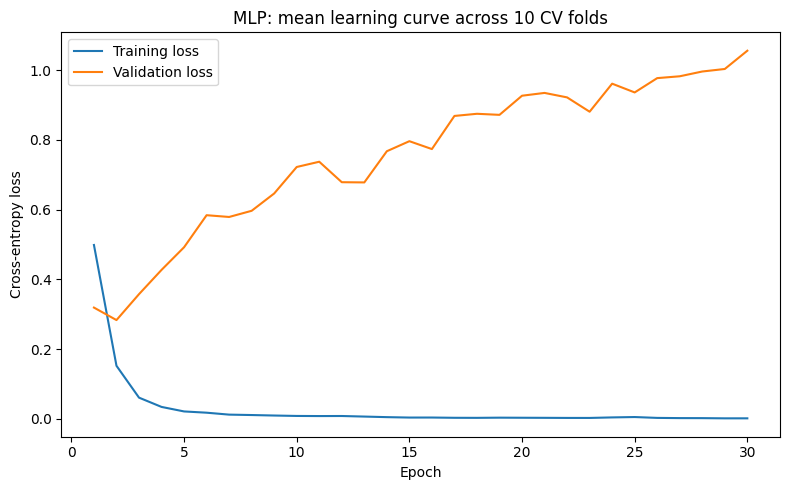

In [6]:
train_losses=np.array([h["train_loss"] for h in histories])
val_losses=np.array([h["val_loss"] for h in histories])
epochs=np.arange(1,EPOCHS+1)
plt.figure(figsize=(8,5))
plt.plot(epochs,train_losses.mean(axis=0),label="Training loss")
plt.plot(epochs,val_losses.mean(axis=0),label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
plt.title("MLP: mean learning curve across 10 CV folds")
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS/"03_mlp_epoch_vs_loss.png",dpi=180)
plt.show()

## Save fold-level and mean±SD results

In [7]:
fold_df.to_csv(RESULTS/"03_mlp_cv_folds.csv",index=False)
pd.DataFrame([summary]).to_csv(RESULTS/"03_mlp_summary.csv",index=False)
print(pd.DataFrame([summary]).to_string(index=False))

      model  n_folds  CV_Train_ROC_AUC_mean  CV_Train_ROC_AUC_std  CV_Train_PR_AUC_active_mean  CV_Train_PR_AUC_active_std  CV_Train_PR_AUC_inactive_mean  CV_Train_PR_AUC_inactive_std  CV_Train_MCC_mean  CV_Train_MCC_std  CV_Train_BalancedAcc_mean  CV_Train_BalancedAcc_std  CV_Train_Recall_active_mean  CV_Train_Recall_active_std  CV_Train_Recall_inactive_mean  CV_Train_Recall_inactive_std  CV_Train_Precision_active_mean  CV_Train_Precision_active_std  CV_Train_Precision_inactive_mean  CV_Train_Precision_inactive_std  CV_Train_Brier_mean  CV_Train_Brier_std  CV_Validation_ROC_AUC_mean  CV_Validation_ROC_AUC_std  CV_Validation_PR_AUC_active_mean  CV_Validation_PR_AUC_active_std  CV_Validation_PR_AUC_inactive_mean  CV_Validation_PR_AUC_inactive_std  CV_Validation_MCC_mean  CV_Validation_MCC_std  CV_Validation_BalancedAcc_mean  CV_Validation_BalancedAcc_std  CV_Validation_Recall_active_mean  CV_Validation_Recall_active_std  CV_Validation_Recall_inactive_mean  CV_Validation_Recall_inactive_